# 协同过滤评估可视化

本 notebook 用于展示基于物品的协同过滤评估流程，包括数据加载、训练/测试划分、单用户推荐、整体指标评估、`top_k` 敏感性分析和可视化。

主模型位于 `src/cf_recommender.py`，评估逻辑位于 `src/evaluation.py`。

## 1. 环境与数据加载

先导入项目模块，并加载评分矩阵。这里会顺手检查 `scikit-learn` 版本，确保当前环境可正常使用。

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from IPython.display import display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cf_recommender import (
    attach_movie_titles,
    compute_item_similarity,
    load_movie_title_map,
    predict_ratings_item_based,
    recommend_items_item_based,
)
from src.evaluation import (
    evaluate_algorithm,
    evaluate_item_cf,
    load_filtered_matrix,
    sensitivity_analysis,
    train_test_split_matrix,
)

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

print('project_root =', project_root)
print('scikit-learn =', sklearn.__version__)


project_root = d:\Movie-Recommender-System
scikit-learn = 1.6.1


In [9]:
matrix = load_filtered_matrix()
n_users, n_items = matrix.shape
n_ratings = int(matrix.notna().sum().sum())
sparsity = 1 - n_ratings / (n_users * n_items)

print('matrix shape:', matrix.shape)
print('ratings:', n_ratings)
print('sparsity:', round(sparsity, 4))
display(matrix.head())


matrix shape: (475, 1617)
ratings: 70454
sparsity: 0.9083


,1,2,3,5,6,7,10,11,12,14,...,138036,139385,142488,148626,152081,158238,164179,166528,168252,176371
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,5.0,4.0,4.0,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. 训练集 / 测试集划分

这里按用户随机抽样测试项，保证训练集和测试集仍保持矩阵结构，便于后续 CF 计算。

In [10]:
train_matrix, test_matrix = train_test_split_matrix(
    matrix,
    test_size=0.2,
    random_state=42,
)

print('train shape:', train_matrix.shape)
print('test shape:', test_matrix.shape)
print('train ratings:', int(train_matrix.notna().sum().sum()))
print('test ratings:', int(test_matrix.notna().sum().sum()))


train shape: (475, 1617)
test shape: (475, 1617)
train ratings: 56361
test ratings: 14093


## 3. 物品相似度与单用户推荐

先计算物品相似度矩阵，再挑选一个样例用户展示 Top-N 推荐结果。如果能读取电影标题映射，则同时展示 `movieId` 与电影名称。

In [11]:
item_sim = compute_item_similarity(train_matrix)
sample_user = train_matrix.index[0]
top_k_neighbors = 20
top_n = 10

preds = predict_ratings_item_based(train_matrix, item_sim, sample_user, top_k=top_k_neighbors)
recs = recommend_items_item_based(train_matrix, sample_user, n=top_n, top_k=top_k_neighbors)

print('sample_user:', sample_user)
display(preds.head(top_n).to_frame('pred_rating'))

try:
    movie_titles = load_movie_title_map(project_root)
    display(attach_movie_titles(recs, movie_titles))
except Exception as exc:
    print('movie title map unavailable:', exc)
    display(pd.DataFrame(recs, columns=['movieId', 'pred_rating']))


sample_user: 1


,pred_rating
54503,4.903361
55765,4.885155
8784,4.871210
54997,4.860665
2968,4.856824
224,4.848297
96821,4.844075
3949,4.843568
5903,4.840725
2394,4.830033


,movieId,title,pred_rating
0,54503,Superbad (2007),4.903361
1,55765,American Gangster (2007),4.885155
2,8784,Garden State (2004),4.871210
3,54997,3:10 to Yuma (2007),4.860665
4,2968,Time Bandits (1981),4.856824
5,224,Don Juan DeMarco (1995),4.848297
6,96821,"Perks of Being a Wallflower, The (2012)",4.844075
7,3949,Requiem for a Dream (2000),4.843568
8,5903,Equilibrium (2002),4.840725
9,2394,"Prince of Egypt, The (1998)",4.830033


## 4. 整体评估

为了让 notebook 运行更稳定，这里默认只取前 `EVAL_USER_COUNT` 个有测试评分的用户做演示。需要全量评估时，把它设成 `None`。

In [12]:
EVAL_USER_COUNT = 20
eval_user_ids = [uid for uid in test_matrix.index if test_matrix.loc[uid].notna().any()]
if EVAL_USER_COUNT is not None:
    eval_user_ids = eval_user_ids[:EVAL_USER_COUNT]

evaluation_result = evaluate_algorithm(
    train_matrix=train_matrix,
    test_matrix=test_matrix,
    algorithm='item',
    top_k_neighbors=20,
    top_n=10,
    relevance_threshold=4.0,
    user_ids=eval_user_ids,
)

display(evaluation_result)
display(evaluation_result.attrs['per_user_results'].head())


,algorithm,top_k_neighbors,top_n,n_users,n_test_ratings,RMSE,MAE,Precision@K,Recall@K
0,sklearn_centered_item_cf,20,10,20,593,0.853986,0.701478,0.04,0.02028


,userId,RMSE,MAE,Precision@K,Recall@K
0,1,0.655157,0.547938,0.0,0.000000
1,4,1.596646,1.406228,0.0,0.000000
2,5,0.805922,0.713664,0.0,0.000000
3,6,0.865518,0.704097,0.1,0.043478
4,7,1.177842,0.855502,0.0,0.000000


## 5. `top_k` 敏感性分析

对不同邻居数进行重复评估，观察 RMSE、MAE、Precision@K 和 Recall@K 的变化趋势。

In [13]:
sensitivity = sensitivity_analysis(
    matrix,
    top_k_values=(5, 10, 20, 40),
    test_size=0.2,
    random_state=42,
    top_n=10,
    relevance_threshold=4.0,
    user_ids=eval_user_ids,
)

display(sensitivity)


,algorithm,top_k_neighbors,top_n,n_users,n_test_ratings,RMSE,MAE,Precision@K,Recall@K
0,sklearn_centered_item_cf,5,10,20,593,0.880942,0.709014,0.045,0.029709
1,sklearn_centered_item_cf,10,10,20,593,0.863147,0.707997,0.060,0.027742
2,sklearn_centered_item_cf,20,10,20,593,0.853986,0.701478,0.040,0.020280
3,sklearn_centered_item_cf,40,10,20,593,0.862422,0.710764,0.020,0.007733


## 6. 评估结果可视化

下面把敏感性分析结果画成折线图，便于比较不同 `top_k` 设置下的指标变化。

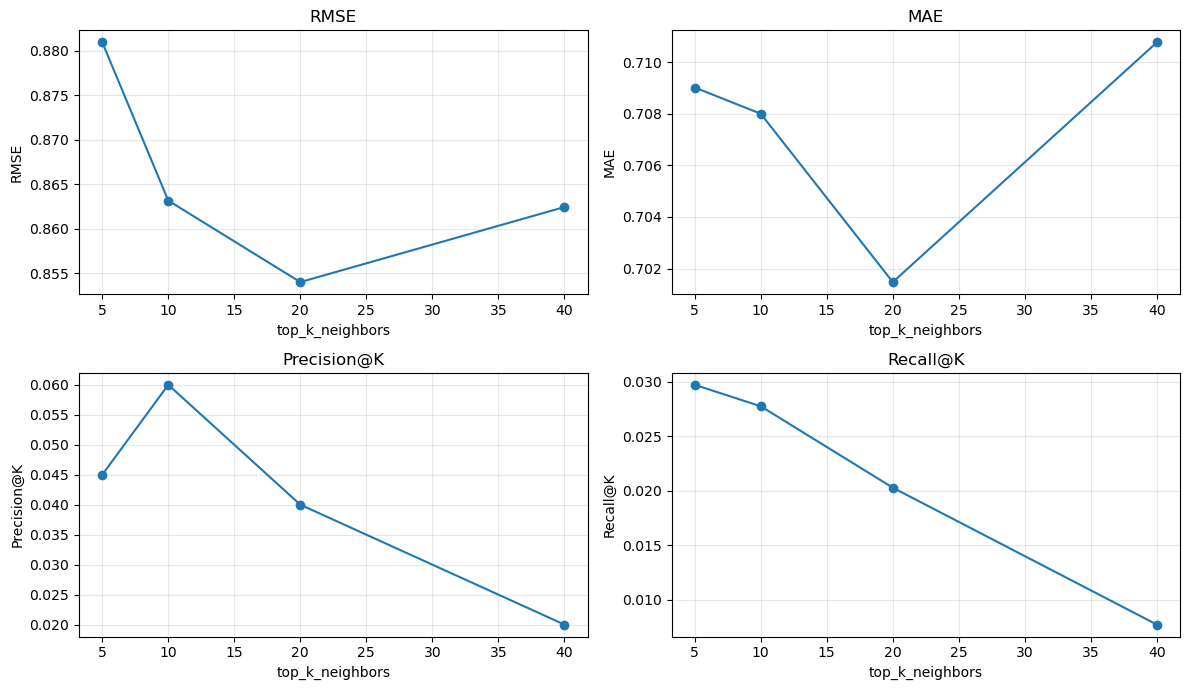

In [14]:
metrics = ['RMSE', 'MAE', 'Precision@K', 'Recall@K']
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()

for ax, metric in zip(axes, metrics):
    ax.plot(sensitivity['top_k_neighbors'], sensitivity[metric], marker='o')
    ax.set_xlabel('top_k_neighbors')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.grid(alpha=0.3)

fig.tight_layout()


## 7. 结论记录

- 主模型为基于物品的协同过滤。
- 评估逻辑统一由 `src/evaluation.py` 提供。
- Notebook 只负责展示和可视化，不再混入算法实现。